# API REST — Predicción de Resultados de Fútbol

**Dataset:** `todas_las_ligas_2025.csv` (se debe cargar en el collab que está adjunto en la entrega del mismo) — 1.266 partidos de 5 ligas europeas (PL, PD, BL1, SA, FL1)

**Objetivo:** Predecir el resultado de un partido: **local** / **empate** / **visitante**

**Estrategia de features:** Como solo tenemos goles (no tiros), construimos estadísticas históricas acumuladas por equipo hasta el momento de cada partido, evitando *data leakage*.

## 1. Instalación de Dependencias

In [17]:
!pip install fastapi uvicorn pyngrok nest-asyncio scikit-learn -q
print('Dependencias instaladas')

Dependencias instaladas


## 2. Carga, Exploración y Feature Engineering

Como el dataset solo tiene goles (los tiros están vacíos), construimos features históricas por equipo:
- Tasa de victorias, empates
- Promedio de goles a favor y en contra
- Diferencias entre local y visitante

Cada feature se calcula solo con partidos anteriores al partido en cuestión, evitando data leakage.

Partidos totales: 1266
Ligas: ['PD', 'FL1', 'PL', 'BL1', 'SA']
Equipos únicos: 96
Columnas con nulos: {'tiros_local': 1266, 'tiros_visitante': 1266}

Distribución de resultados:
resultado
local        559
visitante    388
empate       319
Name: count, dtype: int64


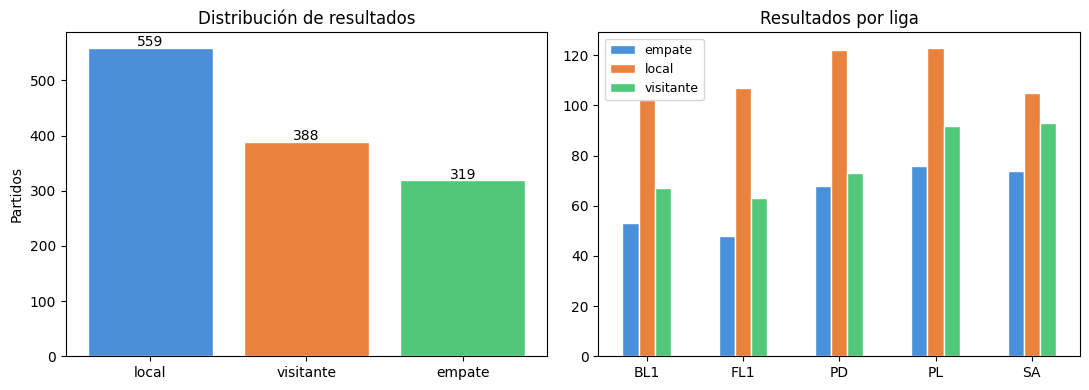


Codificación de ligas: {'BL1': np.int64(0), 'FL1': np.int64(1), 'PD': np.int64(2), 'PL': np.int64(3), 'SA': np.int64(4)}

Features construidas (13):
  - liga_enc
  - local_jugados
  - local_win_rate
  - local_draw_rate
  - local_avg_gf
  - local_avg_gc
  - visita_jugados
  - visita_win_rate
  - visita_draw_rate
  - visita_avg_gf
  - visita_avg_gc
  - diff_win_rate
  - diff_avg_gf

 Feature engineering completado


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('todas_las_ligas_2025.csv')
df = df.sort_values('fecha').reset_index(drop=True)

print(f'Partidos totales: {len(df)}')
print(f'Ligas: {df["liga"].unique().tolist()}')
print(f'Equipos únicos: {df["equipo_local"].nunique()}')
print(f'Columnas con nulos: {df.isnull().sum()[df.isnull().sum() > 0].to_dict()}')

def calcular_resultado(row):
    if row['goles_local'] > row['goles_visitante']:
        return 'local'
    elif row['goles_local'] == row['goles_visitante']:
        return 'empate'
    else:
        return 'visitante'

df['resultado'] = df.apply(calcular_resultado, axis=1)

print(f'\nDistribución de resultados:')
print(df['resultado'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['resultado'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4A90D9', '#E8823C', '#50C878'], edgecolor='white')
axes[0].set_title('Distribución de resultados')
axes[0].set_ylabel('Partidos')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 3, str(val), ha='center', fontsize=10)

by_liga = df.groupby(['liga', 'resultado']).size().unstack(fill_value=0)
by_liga.plot(kind='bar', ax=axes[1], color=['#4A90D9', '#E8823C', '#50C878'], edgecolor='white')
axes[1].set_title('Resultados por liga')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# FEATURE ENGINEERING HISTÓRICO (sin data leakage)
le_liga = LabelEncoder()
df['liga_enc'] = le_liga.fit_transform(df['liga'])
LIGAS_CLASES = le_liga.classes_.tolist()
print(f'\nCodificación de ligas: {dict(zip(LIGAS_CLASES, le_liga.transform(LIGAS_CLASES)))}')

def build_features(df):
    """Construye features históricas por equipo sin data leakage."""
    records = []
    team_stats = {}

    def get_stats(team):
        return team_stats.get(team, {'jugados': 0, 'ganados': 0, 'empatados': 0,
                                      'perdidos': 0, 'gf': 0, 'gc': 0}).copy()

    def win_rate(s):  return s['ganados']   / s['jugados'] if s['jugados'] > 0 else 0.0
    def draw_rate(s): return s['empatados'] / s['jugados'] if s['jugados'] > 0 else 0.0
    def avg_gf(s):    return s['gf']        / s['jugados'] if s['jugados'] > 0 else 0.0
    def avg_gc(s):    return s['gc']        / s['jugados'] if s['jugados'] > 0 else 0.0

    for _, row in df.iterrows():
        local  = row['equipo_local']
        visita = row['equipo_visitante']
        sl = get_stats(local)
        sv = get_stats(visita)

        records.append({
            'liga_enc':          row['liga_enc'],
            'local_jugados':     sl['jugados'],
            'local_win_rate':    win_rate(sl),
            'local_draw_rate':   draw_rate(sl),
            'local_avg_gf':      avg_gf(sl),
            'local_avg_gc':      avg_gc(sl),
            'visita_jugados':    sv['jugados'],
            'visita_win_rate':   win_rate(sv),
            'visita_draw_rate':  draw_rate(sv),
            'visita_avg_gf':     avg_gf(sv),
            'visita_avg_gc':     avg_gc(sv),
            'diff_win_rate':     win_rate(sl) - win_rate(sv),
            'diff_avg_gf':       avg_gf(sl) - avg_gf(sv),
        })

        res = row['resultado']
        for team, gf, gc, won, drew in [
            (local,  row['goles_local'],    row['goles_visitante'], res == 'local',    res == 'empate'),
            (visita, row['goles_visitante'], row['goles_local'],    res == 'visitante', res == 'empate')
        ]:
            if team not in team_stats:
                team_stats[team] = {'jugados': 0, 'ganados': 0, 'empatados': 0,
                                    'perdidos': 0, 'gf': 0, 'gc': 0}
            s = team_stats[team]
            s['jugados']   += 1
            s['ganados']   += int(won)
            s['empatados'] += int(drew)
            s['perdidos']  += int(not won and not drew)
            s['gf'] += gf
            s['gc'] += gc

    return pd.DataFrame(records), team_stats

features_df, team_stats_final = build_features(df)
FEATURE_NAMES = list(features_df.columns)

print(f'\nFeatures construidas ({len(FEATURE_NAMES)}):')
for f in FEATURE_NAMES:
    print(f'  - {f}')
print('\n Feature engineering completado')

## 3. Entrenamiento y Evaluación del Modelo

Partidos con historial suficiente: 1121 de 1266
Train: 896 | Test: 225

Accuracy en test: 0.4400
(Baseline azar: 0.3333)

              precision    recall  f1-score   support

      empate       0.25      0.22      0.24        58
       local       0.51      0.53      0.52        98
   visitante       0.47      0.49      0.48        69

    accuracy                           0.44       225
   macro avg       0.41      0.42      0.41       225
weighted avg       0.43      0.44      0.44       225



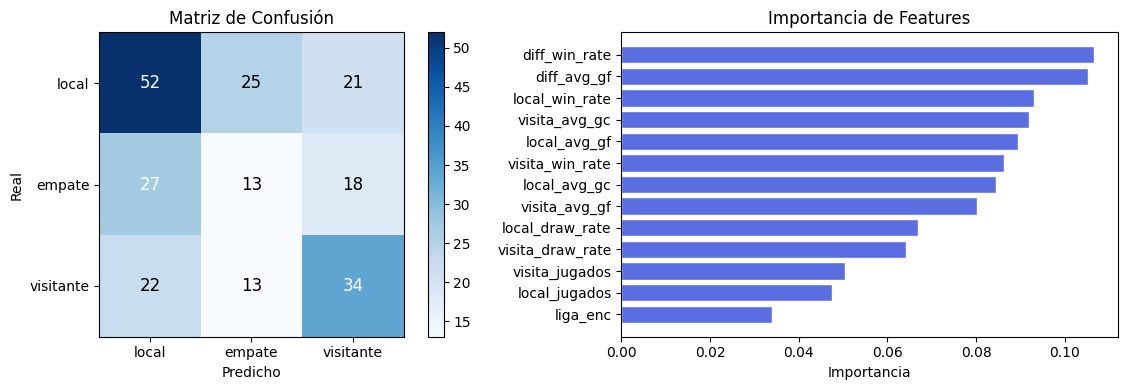


 Modelo guardado en model.pkl
Clases: ['empate', 'local', 'visitante']


In [19]:
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Filtrar partidos con historial suficiente (≥3 partidos previos por equipo)
mask = (features_df['local_jugados'] >= 3) & (features_df['visita_jugados'] >= 3)
X = features_df[mask].values
y = df['resultado'][mask].values
print(f'Partidos con historial suficiente: {mask.sum()} de {len(df)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

# Entrenar
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',   # compensar desbalance de clases
    random_state=42
)
model.fit(X_train, y_train)

# Evaluar
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
CLASS_NAMES = sorted(model.classes_.tolist())  # ['empate', 'local', 'visitante']

print(f'\nAccuracy en test: {acc:.4f}')
print(f'(Baseline azar: {1/3:.4f})')
print()
print(classification_report(y_test, y_pred))

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=['local', 'empate', 'visitante'])
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1,2]); axes[0].set_yticks([0,1,2])
axes[0].set_xticklabels(['local','empate','visitante'])
axes[0].set_yticklabels(['local','empate','visitante'])
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusión')
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=12)
plt.colorbar(im, ax=axes[0])

# Importancia de features
imp = sorted(zip(FEATURE_NAMES, model.feature_importances_), key=lambda x: x[1])
names, vals = zip(*imp)
axes[1].barh(names, vals, color='#5B6EE1', edgecolor='white')
axes[1].set_title('Importancia de Features')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.show()

# Guardar modelo y metadatos
model_data = {
    'model': model,
    'feature_names': FEATURE_NAMES,
    'class_names': CLASS_NAMES,
    'liga_encoder': le_liga,
    'team_stats': team_stats_final,
    'accuracy': round(acc, 4)
}
with open('model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print('\n Modelo guardado en model.pkl')
print(f'Clases: {CLASS_NAMES}')

## 4. Definición de la API FastAPI

In [20]:
api_code = '''
import pickle
import time
import logging
import datetime
from collections import defaultdict
from typing import Optional

import numpy as np
from fastapi import FastAPI, HTTPException, Request
from fastapi.responses import JSONResponse
from pydantic import BaseModel, Field, validator

# ================================================================
# LOGGING
# ================================================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    handlers=[
        logging.FileHandler("app.log"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger("ligas-api")

# ================================================================
# MÉTRICAS EN MEMORIA
# ================================================================
metrics = {
    "total_requests": 0,
    "total_predictions": 0,
    "errors": 0,
    "prediction_counts": defaultdict(int),
    "latencies_ms": [],
    "start_time": datetime.datetime.utcnow().isoformat()
}

# ================================================================
# CARGAR MODELO Y METADATOS
# ================================================================
try:
    with open("model.pkl", "rb") as f:
        data = pickle.load(f)
    model        = data["model"]
    FEATURE_NAMES = data["feature_names"]
    CLASS_NAMES   = data["class_names"]
    le_liga       = data["liga_encoder"]
    team_stats    = data["team_stats"]    # historial por equipo
    MODEL_ACCURACY = data["accuracy"]
    LIGAS_VALIDAS  = le_liga.classes_.tolist()
    logger.info(f"Modelo cargado | accuracy={MODEL_ACCURACY} | clases={CLASS_NAMES}")
except Exception as e:
    logger.critical(f"No se pudo cargar el modelo: {e}")
    raise

# ================================================================
# HELPERS
# ================================================================
def get_team_stats(team: str) -> dict:
    """Obtiene estadísticas históricas de un equipo. Devuelve ceros si es desconocido."""
    return team_stats.get(team, {
        "jugados": 0, "ganados": 0, "empatados": 0,
        "perdidos": 0, "gf": 0, "gc": 0
    })

def rate(s, key): return s[key] / s["jugados"] if s["jugados"] > 0 else 0.0

def build_feature_vector(equipo_local: str, equipo_visitante: str, liga: str) -> np.ndarray:
    """Construye el vector de features para un partido."""
    sl = get_team_stats(equipo_local)
    sv = get_team_stats(equipo_visitante)
    liga_enc = int(le_liga.transform([liga])[0])

    wl  = rate(sl, "ganados")
    wv  = rate(sv, "ganados")
    gfl = rate(sl, "gf")
    gfv = rate(sv, "gf")

    return np.array([[
        liga_enc,
        sl["jugados"],  wl,            rate(sl, "empatados"), gfl,           rate(sl, "gc"),
        sv["jugados"],  wv,            rate(sv, "empatados"), gfv,           rate(sv, "gc"),
        wl - wv,        gfl - gfv
    ]])

# ================================================================
# APP
# ================================================================
app = FastAPI(
    title="Football Match Predictor API",
    description="Predice el resultado (local / empate / visitante) de partidos de fútbol europeo.",
    version="1.0.0"
)

@app.middleware("http")
async def log_requests(request: Request, call_next):
    metrics["total_requests"] += 1
    start = time.perf_counter()
    logger.info(f"→ {request.method} {request.url.path}")
    response = await call_next(request)
    elapsed = round((time.perf_counter() - start) * 1000, 2)
    logger.info(f"← {request.method} {request.url.path} status={response.status_code} | {elapsed} ms")
    return response

# ================================================================
# SCHEMAS
# ================================================================
class MatchRequest(BaseModel):
    equipo_local: str = Field(..., example="Liverpool FC")
    equipo_visitante: str = Field(..., example="Arsenal FC")
    liga: str = Field(..., example="PL",
                      description="Código de liga: PL, PD, BL1, SA, FL1")

    @validator("liga")
    def liga_valida(cls, v):
        validas = ["PL", "PD", "BL1", "SA", "FL1"]
        if v not in validas:
            raise ValueError(f"Liga inválida. Opciones: {validas}")
        return v

class MatchResponse(BaseModel):
    equipo_local: str
    equipo_visitante: str
    liga: str
    prediccion: str
    probabilidades: dict
    confianza: float
    local_historial: dict
    visitante_historial: dict
    model_accuracy: float
    inference_time_ms: float

# ================================================================
# ENDPOINTS
# ================================================================
@app.get("/", tags=["General"])
def root():
    return {
        "message": "Football Match Predictor API — activa",
        "docs": "/docs",
        "ligas_soportadas": LIGAS_VALIDAS,
        "clases": CLASS_NAMES
    }

@app.get("/health", tags=["Monitoreo"])
def health_check():
    try:
        test = build_feature_vector("Test FC", "Test United", "PL")
        model.predict(test)
        logger.info("Health check OK")
        return {"status": "ok", "model": "loaded",
                "timestamp": datetime.datetime.utcnow().isoformat()}
    except Exception as e:
        logger.error(f"Health check FAILED: {e}")
        raise HTTPException(status_code=503, detail=str(e))

@app.get("/metrics", tags=["Monitoreo"])
def get_metrics():
    lats = metrics["latencies_ms"]
    return {
        "start_time":          metrics["start_time"],
        "total_requests":      metrics["total_requests"],
        "total_predictions":   metrics["total_predictions"],
        "errors":              metrics["errors"],
        "predictions_by_class": dict(metrics["prediction_counts"]),
        "latency_ms": {
            "avg":    round(sum(lats) / len(lats), 2) if lats else None,
            "min":    round(min(lats), 2) if lats else None,
            "max":    round(max(lats), 2) if lats else None,
            "last_10": [round(x, 2) for x in lats[-10:]]
        }
    }

@app.get("/model-info", tags=["Modelo"])
def model_info():
    return {
        "algorithm":     "RandomForestClassifier",
        "n_estimators":  model.n_estimators,
        "max_depth":     model.max_depth,
        "classes":       CLASS_NAMES,
        "features":      FEATURE_NAMES,
        "n_features":    model.n_features_in_,
        "accuracy_test": MODEL_ACCURACY,
        "ligas":         LIGAS_VALIDAS,
        "equipos_conocidos": len(team_stats)
    }

@app.get("/equipo/{nombre}", tags=["Equipos"])
def info_equipo(nombre: str):
    """Devuelve el historial estadístico de un equipo."""
    stats = get_team_stats(nombre)
    if stats["jugados"] == 0:
        raise HTTPException(status_code=404,
                            detail=f"Equipo '{nombre}' no encontrado en el historial.")
    jugados = stats["jugados"]
    return {
        "equipo":       nombre,
        "jugados":      jugados,
        "ganados":      stats["ganados"],
        "empatados":    stats["empatados"],
        "perdidos":     stats["perdidos"],
        "goles_favor":  stats["gf"],
        "goles_contra": stats["gc"],
        "win_rate":     round(stats["ganados"] / jugados, 3),
        "avg_goles_favor":  round(stats["gf"] / jugados, 2),
        "avg_goles_contra": round(stats["gc"] / jugados, 2),
    }

@app.get("/equipos", tags=["Equipos"])
def listar_equipos():
    """Lista todos los equipos con historial disponible."""
    return {
        "total": len(team_stats),
        "equipos": sorted(team_stats.keys())
    }

@app.post("/predict", response_model=MatchResponse, tags=["Predicción"])
def predict(payload: MatchRequest):
    """
    Predice el resultado de un partido.

    - **equipo_local**: nombre exacto del equipo local
    - **equipo_visitante**: nombre exacto del equipo visitante
    - **liga**: código de liga (PL, PD, BL1, SA, FL1)

    Devuelve la predicción (local/empate/visitante) con probabilidades
    y el historial estadístico de ambos equipos.
    """
    t0 = time.perf_counter()
    try:
        logger.info(f"Predicción: {payload.equipo_local} vs {payload.equipo_visitante} | {payload.liga}")

        X = build_feature_vector(payload.equipo_local, payload.equipo_visitante, payload.liga)
        pred   = model.predict(X)[0]
        probas = model.predict_proba(X)[0]

        proba_dict = {cls: round(float(p), 4) for cls, p in zip(CLASS_NAMES, probas)}
        confianza  = round(float(max(probas)), 4)
        elapsed_ms = (time.perf_counter() - t0) * 1000

        # Actualizar métricas
        metrics["total_predictions"] += 1
        metrics["latencies_ms"].append(elapsed_ms)
        metrics["prediction_counts"][pred] += 1

        logger.info(f"Resultado: {pred} | confianza={confianza} | {elapsed_ms:.2f} ms")

        sl = get_team_stats(payload.equipo_local)
        sv = get_team_stats(payload.equipo_visitante)

        return MatchResponse(
            equipo_local=payload.equipo_local,
            equipo_visitante=payload.equipo_visitante,
            liga=payload.liga,
            prediccion=pred,
            probabilidades=proba_dict,
            confianza=confianza,
            local_historial={
                "jugados": sl["jugados"],
                "win_rate": round(rate(sl, "ganados"), 3),
                "avg_gf":   round(rate(sl, "gf"), 2)
            },
            visitante_historial={
                "jugados": sv["jugados"],
                "win_rate": round(rate(sv, "ganados"), 3),
                "avg_gf":   round(rate(sv, "gf"), 2)
            },
            model_accuracy=MODEL_ACCURACY,
            inference_time_ms=round(elapsed_ms, 2)
        )

    except HTTPException:
        raise
    except Exception as e:
        metrics["errors"] += 1
        logger.error(f"Error en predicción: {e}")
        raise HTTPException(status_code=500, detail=f"Error en inferencia: {str(e)}")

@app.exception_handler(Exception)
async def global_exception_handler(request: Request, exc: Exception):
    metrics["errors"] += 1
    logger.critical(f"Error no controlado: {exc}")
    return JSONResponse(status_code=500,
                        content={"detail": "Error interno", "error": str(exc)})
'''

with open('api.py', 'w') as f:
    f.write(api_code)

print('api.py generado')
print()
print('Endpoints disponibles:')
endpoints = [
    ('GET',  '/',                   'Raíz — info general'),
    ('GET',  '/health',             'Estado del servicio'),
    ('GET',  '/metrics',            'Métricas de uso'),
    ('GET',  '/model-info',         'Info del modelo'),
    ('GET',  '/equipos',            'Lista todos los equipos'),
    ('GET',  '/equipo/{nombre}',    'Historial de un equipo'),
    ('POST', '/predict',            'Predice resultado de un partido'),
    ('GET',  '/docs',               'Swagger UI interactivo'),
]
for method, path, desc in endpoints:
    print(f'  {method:<5} {path:<25} — {desc}')

api.py generado

Endpoints disponibles:
  GET   /                         — Raíz — info general
  GET   /health                   — Estado del servicio
  GET   /metrics                  — Métricas de uso
  GET   /model-info               — Info del modelo
  GET   /equipos                  — Lista todos los equipos
  GET   /equipo/{nombre}          — Historial de un equipo
  POST  /predict                  — Predice resultado de un partido
  GET   /docs                     — Swagger UI interactivo


## 5. Despliegue con ngrok



In [33]:
import nest_asyncio
import uvicorn
from pyngrok import ngrok, conf
import threading
import importlib.util
import sys

NGROK_AUTH_TOKEN = "2dNRKPXCOcL2Fj8UYfOwjyrC3qO_4WYpzWoz6DaQJQvpoZokU"

nest_asyncio.apply()
conf.get_default().auth_token = NGROK_AUTH_TOKEN
ngrok.kill()

# Importar la app
spec = importlib.util.spec_from_file_location("api", "api.py")
api_module = importlib.util.module_from_spec(spec)
sys.modules["api"] = api_module
spec.loader.exec_module(api_module)
app = api_module.app

# Túnel público
public_url = ngrok.connect(8000)
print(f"\n{'='*60}")
print(f" - URL PÚBLICA : {public_url}")
print(f" - Swagger UI  : {public_url}/docs")
print(f" - Health      : {public_url}/health")
print(f" - Equipos     : {public_url}/equipos")
print(f"{'='*60}\n")

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="warning")

threading.Thread(target=run_server, daemon=True).start()
print('Servidor iniciado en http://localhost:8000')


 - URL PÚBLICA : NgrokTunnel: "https://5a52-34-80-16-51.ngrok-free.app" -> "http://localhost:8000"
 - Swagger UI  : NgrokTunnel: "https://5a52-34-80-16-51.ngrok-free.app" -> "http://localhost:8000"/docs
 - Health      : NgrokTunnel: "https://5a52-34-80-16-51.ngrok-free.app" -> "http://localhost:8000"/health
 - Equipos     : NgrokTunnel: "https://5a52-34-80-16-51.ngrok-free.app" -> "http://localhost:8000"/equipos

Servidor iniciado en http://localhost:8000


ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use


## 6. Pruebas con cURL

In [34]:
# Health check
!curl -s http://localhost:8000/health | python3 -m json.tool

{
    "status": "ok",
    "model": "loaded",
    "timestamp": "2026-04-06T00:16:59.124347"
}


In [35]:
# Predicción: Liverpool FC vs Arsenal FC en Premier League
!curl -s -X POST http://localhost:8000/predict \
  -H "Content-Type: application/json" \
  -d '{"equipo_local": "Liverpool FC", "equipo_visitante": "Arsenal FC", "liga": "PL"}' \
  | python3 -m json.tool

{
    "equipo_local": "Liverpool FC",
    "equipo_visitante": "Arsenal FC",
    "liga": "PL",
    "prediccion": "visitante",
    "probabilidades": {
        "empate": 0.3524,
        "local": 0.1651,
        "visitante": 0.4824
    },
    "confianza": 0.4824,
    "local_historial": {
        "jugados": 29,
        "win_rate": 0.483,
        "avg_gf": 1.66
    },
    "visitante_historial": {
        "jugados": 30,
        "win_rate": 0.667,
        "avg_gf": 1.97
    },
    "model_accuracy": 0.44,
    "inference_time_ms": 64.3
}


In [24]:
# Predicción: Real Madrid vs FC Barcelona en La Liga
!curl -s -X POST http://localhost:8000/predict \
  -H "Content-Type: application/json" \
  -d '{"equipo_local": "Real Madrid CF", "equipo_visitante": "FC Barcelona", "liga": "PD"}' \
  | python3 -m json.tool

{
    "equipo_local": "Real Madrid CF",
    "equipo_visitante": "FC Barcelona",
    "liga": "PD",
    "prediccion": "local",
    "probabilidades": {
        "empate": 0.1897,
        "local": 0.4284,
        "visitante": 0.3819
    },
    "confianza": 0.4284,
    "local_historial": {
        "jugados": 27,
        "win_rate": 0.741,
        "avg_gf": 2.07
    },
    "visitante_historial": {
        "jugados": 26,
        "win_rate": 0.808,
        "avg_gf": 2.73
    },
    "model_accuracy": 0.44,
    "inference_time_ms": 39.47
}


In [25]:
# Liga inválida → debe devolver error 422
!curl -s -X POST http://localhost:8000/predict \
  -H "Content-Type: application/json" \
  -d '{"equipo_local": "Liverpool FC", "equipo_visitante": "Arsenal FC", "liga": "INVALID"}' \
  | python3 -m json.tool

{
    "detail": [
        {
            "type": "value_error",
            "loc": [
                "body",
                "liga"
            ],
            "msg": "Value error, Liga inv\u00e1lida. Opciones: ['PL', 'PD', 'BL1', 'SA', 'FL1']",
            "input": "INVALID",
            "ctx": {
                "error": {}
            }
        }
    ]
}


In [26]:
# Historial de un equipo
!curl -s "http://localhost:8000/equipo/Liverpool%20FC" | python3 -m json.tool

{
    "equipo": "Liverpool FC",
    "jugados": 29,
    "ganados": 14,
    "empatados": 6,
    "perdidos": 9,
    "goles_favor": 48,
    "goles_contra": 39,
    "win_rate": 0.483,
    "avg_goles_favor": 1.66,
    "avg_goles_contra": 1.34
}


In [27]:
# Info del modelo
!curl -s http://localhost:8000/model-info | python3 -m json.tool

{
    "algorithm": "RandomForestClassifier",
    "n_estimators": 200,
    "max_depth": 8,
    "classes": [
        "empate",
        "local",
        "visitante"
    ],
    "features": [
        "liga_enc",
        "local_jugados",
        "local_win_rate",
        "local_draw_rate",
        "local_avg_gf",
        "local_avg_gc",
        "visita_jugados",
        "visita_win_rate",
        "visita_draw_rate",
        "visita_avg_gf",
        "visita_avg_gc",
        "diff_win_rate",
        "diff_avg_gf"
    ],
    "n_features": 13,
    "accuracy_test": 0.44,
    "ligas": [
        "BL1",
        "FL1",
        "PD",
        "PL",
        "SA"
    ],
    "equipos_conocidos": 96
}


## 7. Pruebas con Python requests

In [28]:
import requests
import json

BASE = "http://localhost:8000"

def show(label, r):
    print(f"\n{'─'*55}")
    print(f"  {label}  [HTTP {r.status_code}]")
    print(json.dumps(r.json(), indent=2, ensure_ascii=False))

# Health
show("GET /health", requests.get(f"{BASE}/health"))

# Partidos a predecir
partidos = [
    {"equipo_local": "Liverpool FC",       "equipo_visitante": "Arsenal FC",         "liga": "PL"},
    {"equipo_local": "Real Madrid CF",     "equipo_visitante": "FC Barcelona",        "liga": "PD"},
    {"equipo_local": "FC Bayern München",  "equipo_visitante": "Borussia Dortmund",   "liga": "BL1"},
    {"equipo_local": "Juventus FC",        "equipo_visitante": "SSC Napoli",          "liga": "SA"},
    {"equipo_local": "Paris Saint-Germain FC", "equipo_visitante": "Olympique de Marseille", "liga": "FL1"},
]

for partido in partidos:
    r = requests.post(f"{BASE}/predict", json=partido)
    d = r.json()
    if r.status_code == 200:
        print(f"\n - {partido['equipo_local']} vs {partido['equipo_visitante']} ({partido['liga']})")
        print(f"   Predicción: {d['prediccion'].upper()} | Confianza: {d['confianza']*100:.1f}%")
        print(f"   Probabilidades: {d['probabilidades']}")
    else:
        print(f"   Error: {d}")


───────────────────────────────────────────────────────
  GET /health  [HTTP 200]
{
  "status": "ok",
  "model": "loaded",
  "timestamp": "2026-04-06T00:01:28.851409"
}

 - Liverpool FC vs Arsenal FC (PL)
   Predicción: VISITANTE | Confianza: 48.2%
   Probabilidades: {'empate': 0.3524, 'local': 0.1651, 'visitante': 0.4824}

 - Real Madrid CF vs FC Barcelona (PD)
   Predicción: LOCAL | Confianza: 42.8%
   Probabilidades: {'empate': 0.1897, 'local': 0.4284, 'visitante': 0.3819}

 - FC Bayern München vs Borussia Dortmund (BL1)
   Predicción: LOCAL | Confianza: 78.2%
   Probabilidades: {'empate': 0.0991, 'local': 0.7825, 'visitante': 0.1184}

 - Juventus FC vs SSC Napoli (SA)
   Predicción: VISITANTE | Confianza: 39.5%
   Probabilidades: {'empate': 0.3149, 'local': 0.29, 'visitante': 0.3951}

 - Paris Saint-Germain FC vs Olympique de Marseille (FL1)
   Predicción: LOCAL | Confianza: 63.9%
   Probabilidades: {'empate': 0.1306, 'local': 0.639, 'visitante': 0.2305}


## 8. Monitoreo: Logs y Métricas

In [29]:
import requests, json

# Generar tráfico para poblar las métricas
partidos_test = [
    {"equipo_local": "Liverpool FC",      "equipo_visitante": "Chelsea FC",         "liga": "PL"},
    {"equipo_local": "Manchester City FC","equipo_visitante": "Tottenham Hotspur FC","liga": "PL"},
    {"equipo_local": "Real Madrid CF",    "equipo_visitante": "Atletico de Madrid",  "liga": "PD"},
    {"equipo_local": "FC Bayern München", "equipo_visitante": "Bayer 04 Leverkusen", "liga": "BL1"},
    {"equipo_local": "AC Milan",          "equipo_visitante": "Inter Milan",         "liga": "SA"},
    {"equipo_local": "Paris Saint-Germain FC","equipo_visitante": "AS Monaco FC",    "liga": "FL1"},
]
for p in partidos_test:
    requests.post("http://localhost:8000/predict", json=p)

# Consultar métricas
m = requests.get("http://localhost:8000/metrics").json()
print("MÉTRICAS DEL SERVICIO")
print(json.dumps(m, indent=2))

MÉTRICAS DEL SERVICIO
{
  "start_time": "2026-04-05T23:48:38.233444",
  "total_requests": 46,
  "total_predictions": 32,
  "errors": 0,
  "predictions_by_class": {
    "visitante": 9,
    "local": 20,
    "empate": 3
  },
  "latency_ms": {
    "avg": 23.82,
    "min": 18.71,
    "max": 44.93,
    "last_10": [
      34.15,
      19.71,
      18.71,
      21.07,
      26.55,
      22.44,
      21.24,
      21.65,
      19.86,
      20.24
    ]
  }
}


In [30]:
# Ver últimas líneas del log
print("ÚLTIMAS 30 LÍNEAS DE app.log\n")
try:
    with open('app.log') as f:
        lines = f.readlines()
    for line in lines[-30:]:
        print(line.rstrip())
except FileNotFoundError:
    print('app.log no encontrado. Ejecuta primero algunas predicciones.')

ÚLTIMAS 30 LÍNEAS DE app.log



## 9. Dashboard de Monitoreo

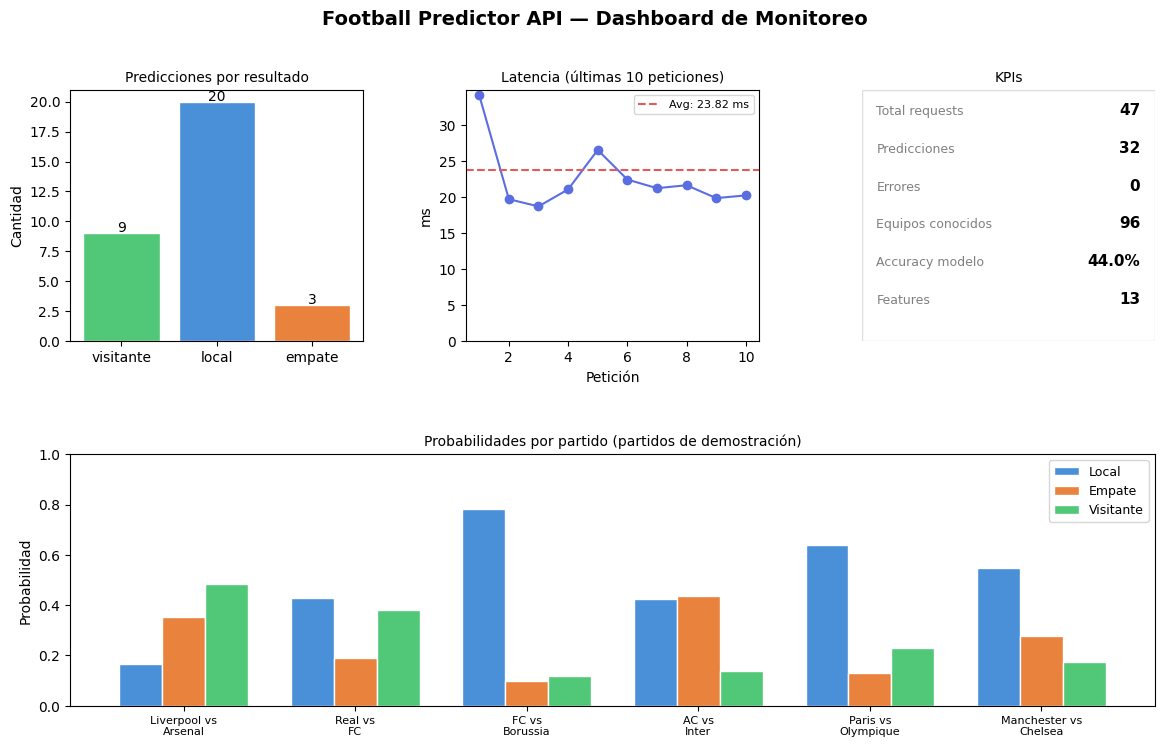

Dashboard guardado como dashboard_monitoreo.png


In [31]:
import requests
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

m = requests.get("http://localhost:8000/metrics").json()
mi = requests.get("http://localhost:8000/model-info").json()

fig = plt.figure(figsize=(14, 8))
fig.suptitle('Football Predictor API — Dashboard de Monitoreo', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

COLORS = {'local': '#4A90D9', 'empate': '#E8823C', 'visitante': '#50C878'}

# --- 1. Predicciones por resultado ---
ax1 = fig.add_subplot(gs[0, 0])
pred_counts = m.get('predictions_by_class', {})
if pred_counts:
    labels = list(pred_counts.keys())
    vals   = list(pred_counts.values())
    colors = [COLORS.get(l, '#888') for l in labels]
    bars = ax1.bar(labels, vals, color=colors, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(v), ha='center', fontsize=10)
ax1.set_title('Predicciones por resultado', fontsize=10)
ax1.set_ylabel('Cantidad')

# --- 2. Latencias ---
ax2 = fig.add_subplot(gs[0, 1])
lats = m['latency_ms'].get('last_10', [])
if lats:
    ax2.plot(range(1, len(lats)+1), lats, marker='o', color='#5B6EE1', linewidth=1.5)
    avg = m['latency_ms']['avg']
    ax2.axhline(avg, color='#E05C5C', linestyle='--', label=f'Avg: {avg} ms')
    ax2.legend(fontsize=8)
    ax2.set_ylim(bottom=0)
ax2.set_title('Latencia (últimas 10 peticiones)', fontsize=10)
ax2.set_xlabel('Petición'); ax2.set_ylabel('ms')

# --- 3. KPIs ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
kpis = [
    ('Total requests',    m['total_requests']),
    ('Predicciones',      m['total_predictions']),
    ('Errores',           m['errors']),
    ('Equipos conocidos', mi['equipos_conocidos']),
    ('Accuracy modelo',   f"{mi['accuracy_test']*100:.1f}%"),
    ('Features',          mi['n_features']),
]
for i, (label, val) in enumerate(kpis):
    ax3.text(0.05, 0.9 - i*0.15, label, fontsize=9,
             color='gray', transform=ax3.transAxes)
    ax3.text(0.95, 0.9 - i*0.15, str(val), fontsize=11,
             fontweight='bold', ha='right', transform=ax3.transAxes)
ax3.set_title('KPIs', fontsize=10)
ax3.add_patch(plt.Rectangle((0,0),1,1, fill=False,
              edgecolor='#ddd', linewidth=1, transform=ax3.transAxes))

# --- 4. Distribución de probabilidades ---
ax4 = fig.add_subplot(gs[1, :])
# Obtener probabilidades de varios partidos para visualizar distribución
partidos_demo = [
    ("Liverpool FC", "Arsenal FC", "PL"),
    ("Real Madrid CF", "FC Barcelona", "PD"),
    ("FC Bayern München", "Borussia Dortmund", "BL1"),
    ("AC Milan", "Inter Milan", "SA"),
    ("Paris Saint-Germain FC", "Olympique de Marseille", "FL1"),
    ("Manchester City FC", "Chelsea FC", "PL"),
]
x = np.arange(len(partidos_demo))
width = 0.25
proba_local, proba_emp, proba_vis = [], [], []
labels_partidos = []

for local, visita, liga in partidos_demo:
    r = requests.post("http://localhost:8000/predict",
                      json={"equipo_local": local, "equipo_visitante": visita, "liga": liga})
    if r.status_code == 200:
        p = r.json()['probabilidades']
        proba_local.append(p.get('local', 0))
        proba_emp.append(p.get('empate', 0))
        proba_vis.append(p.get('visitante', 0))
        labels_partidos.append(f"{local.split()[0]} vs\n{visita.split()[0]}")

if proba_local:
    ax4.bar(x - width, proba_local, width, label='Local',     color=COLORS['local'],     edgecolor='white')
    ax4.bar(x,         proba_emp,   width, label='Empate',    color=COLORS['empate'],    edgecolor='white')
    ax4.bar(x + width, proba_vis,   width, label='Visitante', color=COLORS['visitante'], edgecolor='white')
    ax4.set_xticks(x)
    ax4.set_xticklabels(labels_partidos, fontsize=8)
    ax4.set_ylabel('Probabilidad')
    ax4.set_title('Probabilidades por partido (partidos de demostración)', fontsize=10)
    ax4.legend(fontsize=9)
    ax4.set_ylim(0, 1)

plt.savefig('dashboard_monitoreo.png', dpi=110, bbox_inches='tight')
plt.show()
print('Dashboard guardado como dashboard_monitoreo.png')

## Ejemplos de consultas con Postman

Usar la URL pública de ngrok generada en la Celda 5.

### Predecir un partido
```
Método:  POST
URL:     https://<url-ngrok>/predict
Headers: Content-Type: application/json
Body:
{
  "equipo_local": "Liverpool FC",
  "equipo_visitante": "Arsenal FC",
  "liga": "PL"
}
```

### Ligas disponibles
| Código | Liga |
|--------|------|
| PL  | Premier League (Inglaterra) |
| PD  | La Liga (España) |
| BL1 | Bundesliga (Alemania) |
| SA  | Serie A (Italia) |
| FL1 | Ligue 1 (Francia) |

### Ver equipos disponibles
```
GET https://<url-ngrok>/equipos
```

### Ver historial de un equipo
```
GET https://<url-ngrok>/equipo/Liverpool FC
```

In [32]:
# Detener el túnel ngrok cuando se termine las pruebas
from pyngrok import ngrok
ngrok.kill()
print('Túnel ngrok cerrado')

Túnel ngrok cerrado
